# 1. 摄像头对象

## 1.1 环境

In [ ]:
# opencv
!pip install opencv-python
# yolo网络
!pip install ultralytics 
# transformers
!pip install transformers==4.57.3
# 安装环境
!pip show transformers
# opencv高级
!pip install opencv-contrib-python
# 可视化
!pip install matplotlib 

## 1.2 文档

- 官方：
    - opencv：`https://docs.opencv.org/`
    - transformers：`https://huggingface.co/docs/transformers/index`
    - yolo：
        - `https://github.com/ultralytics/ultralytics`
        - `https://docs.ultralytics.com/`

## 1.3. 示例

### (1) 打开摄像头

In [3]:
import cv2

# 使用cv2 的VideoCapture()方法
#    默认第一个摄像头 是0---> 即dev = cv2.VideoCapture(0)
#    注意，此方法也可以适用视频 "视频路径"----->即dev = cv2.VideoCapture("视频路径")
dev = cv2.VideoCapture(0)


fps   = dev.get(cv2.CAP_PROP_FPS)
frame = dev.get(cv2.CAP_PROP_FRAME_COUNT)
hight = dev.get(cv2.CAP_PROP_FRAME_HEIGHT)
width  = dev.get(cv2.CAP_PROP_FRAME_WIDTH)

print(f"{fps=},{frame=},{hight=},{width=}")   
#fps=30.0,frame=-1.0,hight=480.0,width=640.0

fps=30.0,frame=-1.0,hight=480.0,width=640.0


### (2) 读取视频帧

In [11]:
print(cv2.__version__)

4.13.0


In [4]:
dev = cv2.VideoCapture(0)
# 返回第一个值：读取的状态，True成功。False表示失败，
# 返回第二个值： 图像（图像上的全部像素） （长，宽，颜色通道）   如果颜色通道为3 即是说 三色相叠 是彩色图
status, frame = dev.read()
dev.release()
frame.shape
#（480，640，3）

(480, 640, 3)

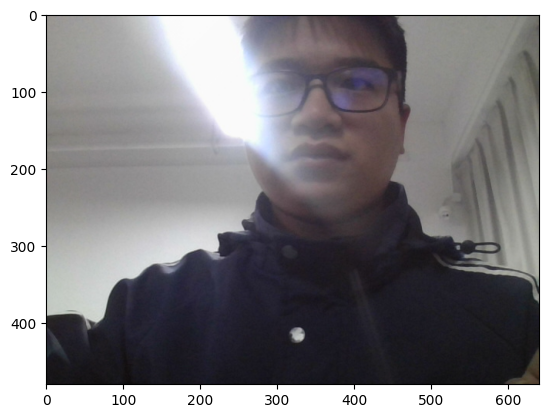

In [ ]:
import matplotlib.pyplot as plt
import cv2
dev = cv2.VideoCapture(0)

#使用cv2的read() 函数来获取  读取状态，视频帧 
status, frame = dev.read()

dev.release()

#！！！ 注意这里有个颜色格式的转换bgr-->rgb
# 原因是，cv2 使用bgr格式 而pyplot使用rgb格式   如果不转换照片会出现绿红原色相反
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

#使用pyplot 的imshow() 堆加图像  注意：可以堆砌多层
plt.imshow(frame)

#使用pyplot 的show() 来显示堆加的图像
plt.show()

### (3) 显示视频

In [5]:
import cv2
dev = cv2.VideoCapture(0)

#思路：持续不断的使用dev.read() 来获取视频的帧
while True:
    status, frame = dev.read()
    if status == True:
        cv2.imshow("Image", frame)
        # 按键退出
        if cv2.waitKey(80) == ord('q'):
            break
    else:
        print("读取失败！")
        break


# 完成任务释放资源
dev.release()
cv2.destroyAllWindows()

# 2. 图像处理

## 2.1. 视频绘制文本

In [10]:
#我们可以获取视频了， 那么接下来 尝试对视频添加一些 文本 或者 图像

import cv2
dev     =  cv2.VideoCapture(0)
fps     =  int(dev.get(cv2.CAP_PROP_FPS))
width   =  int(dev.get(cv2.CAP_PROP_FRAME_WIDTH))
height  =  int(dev.get(cv2.CAP_PROP_FRAME_HEIGHT))


while True:
    status, frame = dev.read()
    if status == True:
        #----------------图形处理（opencv 绘制功能）---------------------
        # cv2.putText(
        #     frame, 
        #     text=F"Video Info({width} x {height:04d}), FPS={fps}",
        #     fontFace=0,  # 字体名
        #     fontScale=0.7,   # 缩放
        #     color=(0, 255, 255), # 颜色 
        #     thickness=2,  # 粗细
        #     org=(10, 30))  # 位置
        # 两种参数：位置参数+关键字参数

        # cv2.rectangle(frame, (100, 100, 200, 200), (0, 255, 0), 3)
        # cv2.rectangle(frame, (150, 150), (350, 350), (255, 0, 0), 1)     
        # cv.Sobel(	src, ddepth, dx, dy[, dst[, ksize[, scale[, delta[, borderType]]]]]	) ->	dst

        frame=cv2.putText(frame,text="Hello world",org=(100,50),fontFace=0,fontScale=0.7,color =(0,255,255))
        #frame = cv2.Sobel(frame, -1, dx=2, dy=1, ksize=3, scale=1.0, delta=180)
        # -------------------------------------
        cv2.imshow("Image", frame)
        # 按键退出
        if cv2.waitKey(80) == ord('q'):
            break
    else:
        print("读取失败！")
        break

# 完成任务释放资源
dev.release()
cv2.destroyAllWindows()

- 代码说明：
    - 调用中参数的使用两种方式：
        - 位置参数：原来文档的顺序完全一致。
        - 关键字参数：不讲究顺序
        - 注意：关键字参数以后的参数必须都是关键字参数。
    - 格式字符串
        - F"XXX{变量}"
        - 变量: 0长度.+小数位数+类型
            - 类型：d整数，f小数。

## 2.2. 视频绘制简单的几何图形

- 圆，椭圆，矩阵，箭头，标记，多边形etc...

- 矩形绘制：
    - rectangle

- 注意：
    - 更多：
        - 图像运算
        - 图形的形态学。
        - 图像的特征(滤波)处理（卷积，高斯，sobel， laplace）

- 任务：
    - 独自重写视频抓取的程序。
    - 完成如下图像处理：
        - 文本
        - 椭圆
        - sobel
    - 调整参数：
        - 文本调整个人喜欢的风格。
        - 文本内容可以改变：绘制日期。（使用DeepSeek：python获取日期的年月日，时分秒）
    - 使用图形绘制，修饰视频。
        - 视频加一个边框。
    - 尝试使用图形绘制的其他形状。

- 总结：
    - 字符串格式：参考我们文档。
    - git的使用

# 3. 模型的使用

## 3.1 Transformers的模型使用

- transformers的模型的基本实现结构
    - 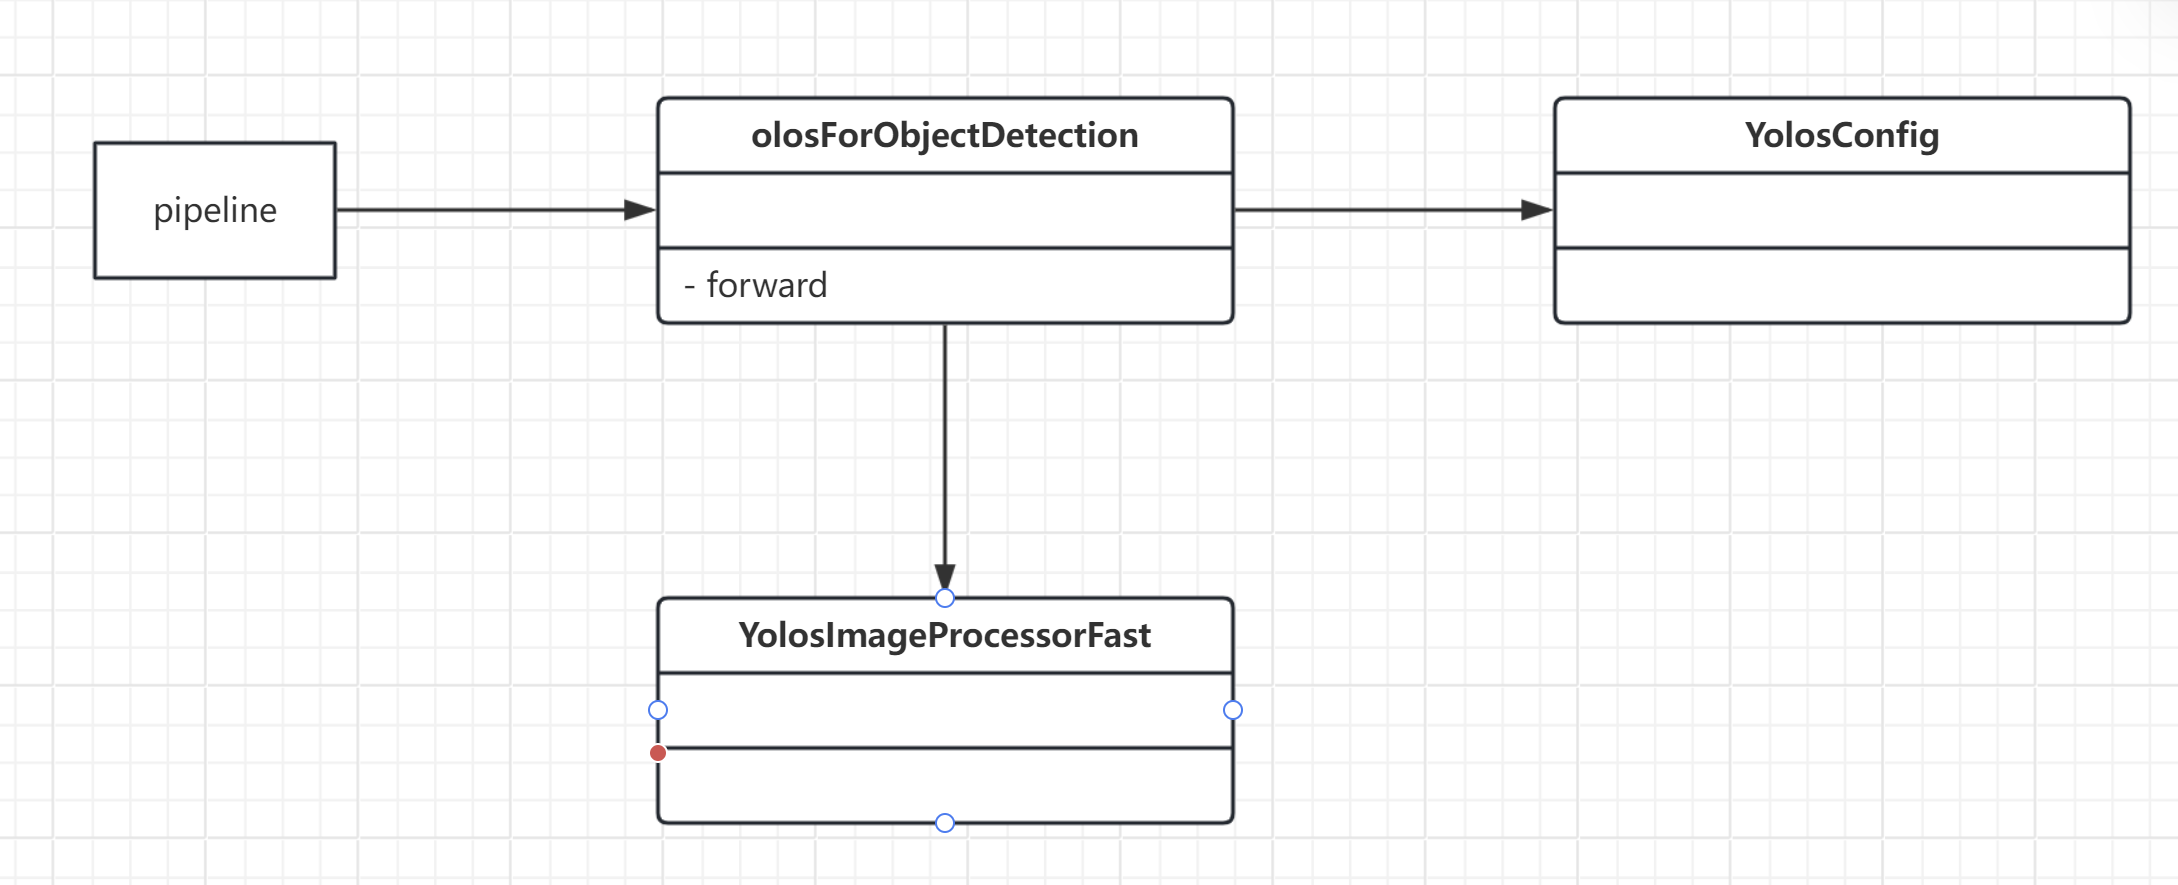

- transformers：
    - **模型下载**
    - **pipeline简单使用**
    - 使用YolosForObjectDetection及其相关的类，实现更大的功能。
    - 使用多个模型进行评估：
        - 速度
        - 精确度
        - 模型大小(量化：提速，压缩)
    - 迁移学习 + 微调
    - 从新训练
    - 重新改进模型：
        - 数据预处理
        - 推理
        - 推理结果处理

In [13]:
from transformers import pipeline
pipe = pipeline(task="object-detection", model="E:/models/yolos-tiny")
print(type(pipe.model))
print(type(pipe.model.config))
print(type(pipe.processor))
print(type(pipe.image_processor))
print(type(pipe.feature_extractor))
print(type(pipe.tokenizer))

"""
_load_processor = False
    _load_image_processor = True
    _load_feature_extractor = False
    _load_tokenizer = False
"""


pipe("../../assets/images/04_traffic.jpg")

Device set to use cuda:0


<class 'transformers.models.yolos.modeling_yolos.YolosForObjectDetection'>
<class 'transformers.models.yolos.configuration_yolos.YolosConfig'>
<class 'NoneType'>
<class 'transformers.models.yolos.image_processing_yolos.YolosImageProcessor'>
<class 'NoneType'>
<class 'NoneType'>


[{'score': 0.609562873840332,
  'label': 'umbrella',
  'box': {'xmin': 85, 'ymin': 111, 'xmax': 174, 'ymax': 210}},
 {'score': 0.7884128093719482,
  'label': 'person',
  'box': {'xmin': 592, 'ymin': 243, 'xmax': 661, 'ymax': 348}},
 {'score': 0.9889712929725647,
  'label': 'person',
  'box': {'xmin': 900, 'ymin': 368, 'xmax': 989, 'ymax': 531}},
 {'score': 0.9971381425857544,
  'label': 'person',
  'box': {'xmin': 630, 'ymin': 308, 'xmax': 742, 'ymax': 529}},
 {'score': 0.9427825808525085,
  'label': 'person',
  'box': {'xmin': 952, 'ymin': 0, 'xmax': 1017, 'ymax': 113}},
 {'score': 0.6816450357437134,
  'label': 'umbrella',
  'box': {'xmin': 79, 'ymin': 114, 'xmax': 173, 'ymax': 181}},
 {'score': 0.9599080681800842,
  'label': 'umbrella',
  'box': {'xmin': 81, 'ymin': 114, 'xmax': 170, 'ymax': 156}},
 {'score': 0.9427143335342407,
  'label': 'person',
  'box': {'xmin': 216, 'ymin': 355, 'xmax': 282, 'ymax': 488}},
 {'score': 0.8612076640129089,
  'label': 'person',
  'box': {'xmin': 1

In [14]:
import cv2
from transformers import pipeline
from PIL import Image

# dev = cv2.VideoCapture("./street_corner.mp4")
dev = cv2.VideoCapture(0)
fps = int(dev.get(cv2.CAP_PROP_FPS))
width = int(dev.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(dev.get(cv2.CAP_PROP_FRAME_HEIGHT))

# 1. 加载模型到管道
object_detect = pipeline(task="object-detection", model="E:/models/yolos-tiny")

# 返回第一个值：读取的状态，True成功。False表示失败，frame返回图像。
while True:
    status, frame = dev.read()
    if status == True:
        # ----------------调用模型实现目标侦测---------------------
        # 2. 执行推理
        img = Image.fromarray(frame)
        results = object_detect(img)  # 参数支持的格式：文件名，张量，PIL.Image，Dataset

        # 使用图像处理技术实现目标标注
        for a_obj in results:
            prob  = a_obj["score"]
            label = a_obj["label"]
            bbox  = a_obj["box"]
            xmin = bbox["xmin"]
            ymin = bbox["ymin"]
            xmax = bbox["xmax"]
            ymax = bbox["ymax"]
            if prob >= 0.90:
                cv2.rectangle(frame, pt1=(xmin, ymin), pt2=(xmax, ymax), color=(0, 255, 0), thickness=2)
                cv2.putText(frame, F"{label}:{prob:.2f}", org=(xmin, ymin-20), color=(255, 0, 0), thickness=1, fontFace=0, fontScale=0.5)
            
        # -------------------------------------
        cv2.imshow("Image", frame)
        # 按键退出
        if cv2.waitKey(80) == ord('q'):
            break
    else:
        print("读取失败！")
        break

# 完成任务释放资源
dev.release()
cv2.destroyAllWindows()

Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


- 代码说明：
    - 怎么找到自己需要的模型：
        - 根据任务去找。
        - 跟算法去找。
    - 可调用对象：
        - 必须有一个运算符：`__call__` 

- 总结：
    - 机器视觉类的应用开发需要的技能：
        - 机器视觉的模型与算法。
        - 图像处理技术（文本，几何图形，图像运算）
        - UI：GUI（Qt），WUI（FastAPI）。

### (3) 总结

In [15]:
# 引入模块
import cv2   # 负责图像处理 + 图形界面
import transformers  # 负责模型加载与推理（算法，训练，推理，评估）
import time  # 获取系统时间

In [16]:
# 打开摄像头
dev_video = cv2.VideoCapture("./street_corner.mp4") 

In [17]:
dev_video

< cv2.VideoCapture 000002D15D21BDF0>

In [18]:
# 获取视频信息 - 视频宽度
width = int(dev_video.get(cv2.CAP_PROP_FRAME_WIDTH))

In [19]:
width

640

In [20]:
# 获取视频信息 - 视频高度
height = int(dev_video.get(cv2.CAP_PROP_FRAME_HEIGHT))

In [21]:
height

368

In [22]:
# 获取视频信息 - FPS（每秒帧数）
fps = int(dev_video.get(cv2.CAP_PROP_FPS))

In [23]:
fps

29

In [24]:
# 获取视频信息 - 视频总的帧数
count = int(dev_video.get(cv2.CAP_PROP_FRAME_COUNT))

In [25]:
count

5122

In [26]:
# 播放时间
play_time = count / fps

In [27]:
play_time

176.6206896551724

---

In [1]:
# 引入模块
import cv2   # 负责图像处理 + 图形界面
import transformers  # 负责模型加载与推理（算法，训练，推理，评估）
import time  # 获取系统时间
import PIL  # 模型推理需要PIL.Image格式
# 打开摄像头
dev_video = cv2.VideoCapture("./street_corner.mp4") 
# 获取视频信息 - 视频宽度
width = int(dev_video.get(cv2.CAP_PROP_FRAME_WIDTH))
# 获取视频信息 - 视频高度
height = int(dev_video.get(cv2.CAP_PROP_FRAME_HEIGHT))
# 获取视频信息 - FPS（每秒帧数）
fps = int(dev_video.get(cv2.CAP_PROP_FPS))
# 获取视频信息 - 视频总的帧数
count = int(dev_video.get(cv2.CAP_PROP_FRAME_COUNT))
# 播放时间
play_time = count / fps
######################################################################
# 1. 加载模型
pipe = transformers.pipeline(task="object-detection", model="./yolos-tiny", device="cuda", use_fast=True)
######################################################################
# 使用死循环读取视频
while True:
    # 读取
    status, image = dev_video.read()
    if status:
        ############################################################
        # 2. 图像预处理（推理不支持数组，必须转换为Image，Tensor）
        img_pil = PIL.Image.fromarray(image)  # 把opencv中的图像格式，转换为PIL.Image
        # 3. 推理
        objects = pipe(img_pil)
        # 4. 推理结果处理
        for obj in objects:
            # 解析值
            score = obj["score"]
            label = obj["label"]
            box   = obj["box"]

            x1 = box["xmin"]
            y1 = box["ymin"]

            x2 = box["xmax"]
            y2 = box["ymax"]
            # 使用解析值标注
            if label in ["bus", "person"]:
                # 目标标注
                cv2.rectangle(image, pt1=(x1, y1), pt2=(x2, y2), color=(0, 255, 255), thickness=2)
                # 目标说明
                color = (0, 255, 0) if label=="person" else (0, 0, 255)
                cv2.putText(image, F"{label}-{score:.2f}", org=(x1, y1 - 5), color=color, fontFace=0, fontScale=0.5, thickness=2)
        ############################################################
        # 显示（使用opencv高级图形界面窗口）
        cv2.imshow("Monitor", image)
        # 暂停（因为视觉的缘故）：暂停的时间int（1000毫秒/fps）
        key = cv2.waitKey(int(1000/fps))
        # 判定键值：如果是ESC键，则退出
        if key == 27:
            print("按键退出")
            break;
    else:
        print("读取失败，或者播放完毕")
        break
# 释放 - 视频
dev_video.release()
# 释放 - 显示窗体
cv2.destroyAllWindows()

W0319 16:53:29.764000 29988 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


按键退出


- torch的gpu版本安装；
    - `pip install torch torchvision torchaudio torchtext torchao --index-url https://download.pytorch.org/whl/cu128`

- 任务：
    - 单独使用transformers加载yolo模型。观察推理结果的数据格式：
        - list类型，元素是字典类型。
    - 使用git下载yolo的其他模型，对比推理结果：概率（score）
        - tiny，small
        - 下载地址：modelscope.cn + huggingface.co
            - `git clone https://huggingface.co/hustvl/yolos-tiny`
    - 完成目标侦测与标注。
        - 在视频中集成目标侦测，并且标注
        - 视频信息标注
        - 时间标注。
    - 可选：
        - 卸载英伟达显卡驱动，安装我们指定的驱动。
        - 驱动下载deepseek，下载地址
        - 看看输出提示，是否使用的是GPU。任务管理器直接观察显卡内存。

- 代码仓库的要求：
    - 首页的README.md文档结构清晰，体验度高：每天的程序的运行的界面截图。
    - 每个目录下有一个README.md

## 3.2. 第三方模型